
# California Housing Price Prediction using Linear Regression
Step 1: Import Libraries **bold text**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Step 2: Load the Dataset**

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


What is housing.data?

It contains the actual numbers.
housing.data[:3]

In [3]:
# housing.data[start:end]
#housing.data[:3] is equivalent to ( housing.data[0:3] )  It will show the first 3 rows of the dataset.
# Since the California Housing dataset has 8 features (columns), the output will contain: 3 rows 8 values in each row
# Show rows 10 to 19:  housing.data[10:20] last index is not readable
# So housing.data[:3] displays only 3 out of 20,640 rows

housing.data[:3]

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02]])

In [ ]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


| Key           | Description         |
| ------------- | ------------------- |
| data          | House features      |
| target        | House prices        |
| feature_names | Names of columns    |
| DESCR         | Dataset description |


## step 03 Display the Dataset

In [ ]:

#explore the data
print(df.shape)
df.info()
df.describe()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Check Missing Values

In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


Step 5: Exploratory Data Analysis (EDA)
Correlation Matrix

1.1 Correlation Matrix

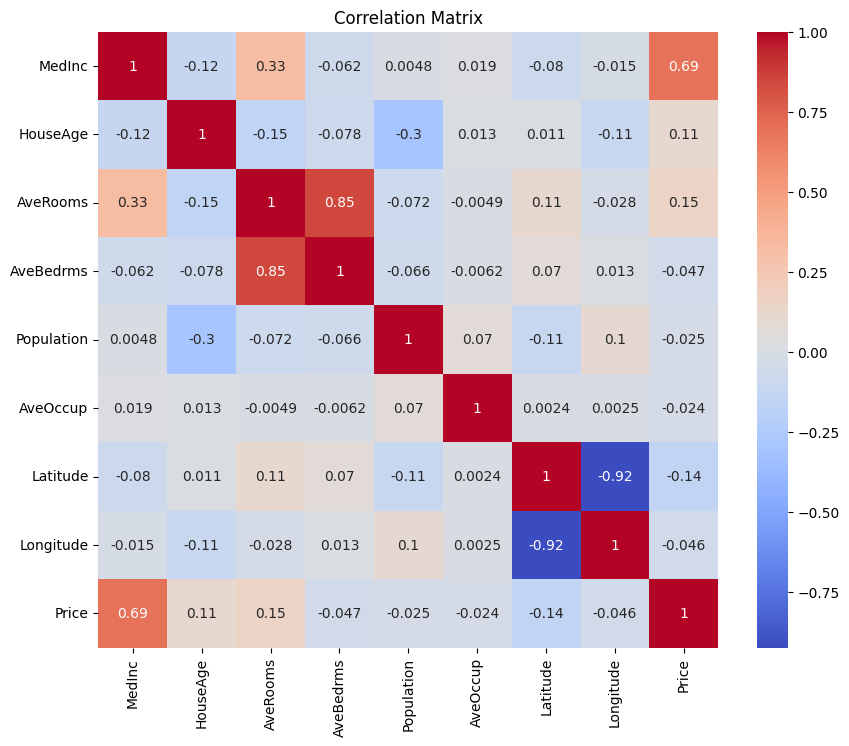

In [ ]:
plt.figure(figsize=(10,8),dpi=100) # dpi is for making resolution much better
# plt.figure(facecolor="pink") # to change its  backgroudn color
#df.corr(method='pearson')
#  df.corr(method='pearson') use for Linear relationships
# df.corr(method='spearman') use for Ranked/monotonic relationships
# df.corr(method='kendall')  Small datasets or many tied ranks
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
# annot= ture and annot =false it shows and hide number on the graph
#cmap is like we can change the color of the map.preferably we use cmap=coolwarm
plt.title("Correlation Matrix")
plt.show()

1.2 Distribution of House Prices



1. plt.figure(figsize=(8,5)) creates a figure with a width of 8 inches and a
height of 5 inches for displaying the graph clearly.
2. sns.histplot(df["Price"], bins=30, kde=True) creates a histogram of the Price column to show how house prices are distributed. The bins=30 parameter divides the data into 30 intervals (bars), making it easier to see the frequency of different price ranges. The kde=True parameter adds a smooth density curve that helps visualize the overall distribution pattern of the data.

1. plt.title("Distribution of House Prices") adds a title to the graph, and plt.show() displays the completed histogram.



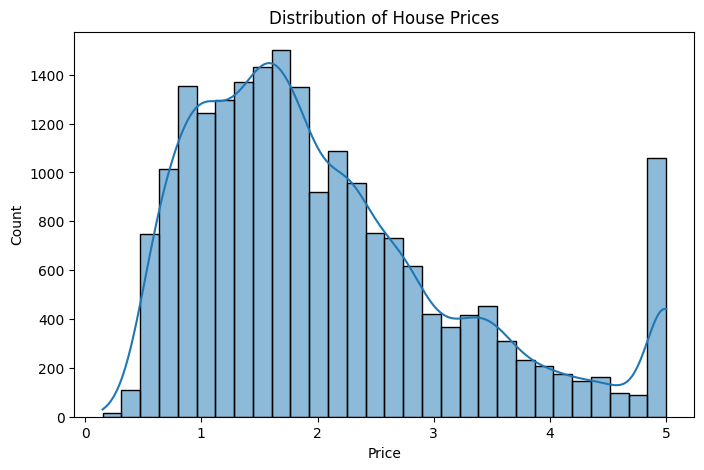

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

### In data analysis and machine learning, different types of charts are used to understand and visualize data. A Histogram shows the distribution of numerical data, while a Box Plot helps identify outliers and displays the spread of the data. A Scatter Plot is used to examine the relationship between two numerical variables, and a Line Plot is useful for showing trends over time. A Bar Plot compares values across different categories, whereas a Count Plot displays the frequency of each category. A Heatmap visualizes the correlation between variables, making it easier to identify relationships among features. A Pair Plot provides a quick overview of relationships and distributions for multiple numerical variables, and a Violin Plot combines the features of a box plot and a density plot to show the distribution of data. Choosing the appropriate visualization helps in understanding the dataset, identifying patterns, detecting anomalies, and making informed decisions before building a machine learning model.



1.   Histogram – Understand data distributions
1.   Box Plot – Detect outliers
2.   Scatter Plot – Explore relationships
1.   Bar Plot – Compare categories
1.   Count Plot – Analyze categorical variables
1.   Heatmap – Feature correlation
2.   Pair Plot – Quick exploration of numerical features
2.   Line Plot – Time series and trends
2.   Violin Plot – Compare distributions across groups
2.   Regression Plot (regplot) – Visualize linear relationships

These ten plots cover the vast majority of exploratory data analysis tasks you'll encounter in machine learning projects and technical interviews

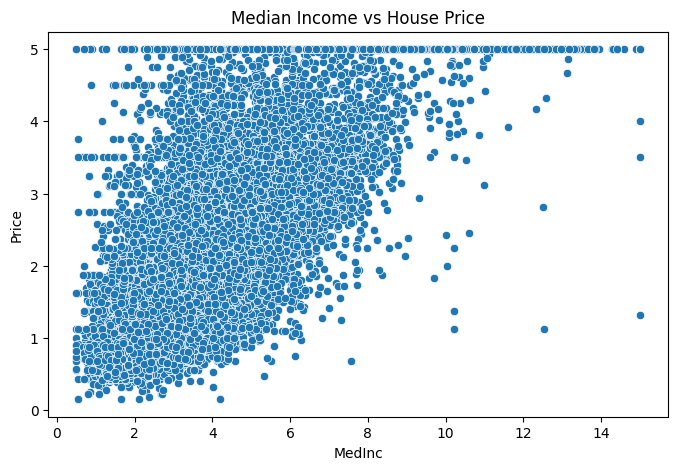

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["MedInc"], y=df["Price"])
plt.title("Median Income vs House Price")
plt.show()